# Visual check — does T2S track what the video shows?

Loads the current T2S model, rolls out several policies on the **fixed scene**,
and renders each as a video with the predicted-steps curve alongside, frame
markers included so you can pause the video and read the number at that
instant.

Not a new evaluation metric — this is a sanity check for eyeballing whether
the prediction curve is doing something sensible relative to what the arm is
visibly doing.

## 1. Setup

In [10]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
import os, json, pickle, glob
import imageio
import matplotlib.pyplot as plt
from stable_baselines3 import SAC
from IPython.display import Video

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"
OBS_DIM = 39
HAND_POS_IDX = [0, 1, 2]
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

def find_wrapper(env, attr):
    w = env
    while not hasattr(w, attr):
        if not hasattr(w, "env"):
            raise AttributeError(attr)
        w = w.env
    return w

## 2. The scene — fixed vs. random, explicit choice

Two constructors, so you can check the model under either condition on
purpose rather than by accident. See the discussion cell below on why the
scene has been fixed in every dataset/RL run so far, and what changes if it
is not.

In [11]:
DATASET_DIR = "./data/state_space_datasetV7"
FIXED_TASK_PATH = os.path.join(DATASET_DIR, "fixed_task.pkl")

def make_fixed_scene_env(render_mode=None, seed=0):
    """Same peg/goal position every reset — what the T2S model was trained on."""
    env = make_env(seed=seed, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        env.unwrapped.set_task(pickle.load(f))
    return env

def make_random_scene_env(render_mode=None, seed=0):
    """Peg/goal randomize on reset, MetaWorld's default. The T2S model has
    NEVER seen this distribution — use for a deliberate out-of-scope check,
    not as a standard evaluation."""
    env = make_env(seed=seed, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(True)
    return env

_e = make_fixed_scene_env()
_o1, _ = _e.reset(seed=1); _o2, _ = _e.reset(seed=2); _e.close()
print("fixed scene confirmed:", np.allclose(_o1[PEG_POS_IDX+GOAL_POS_IDX],
                                              _o2[PEG_POS_IDX+GOAL_POS_IDX]))

fixed scene confirmed: True


## 3. Load the T2S model currently in use

In [12]:
# T2S_MODEL_DIR = "./checkpoints/t2s_staged_v8"    # point this at whichever version you want to check
T2S_MODEL_DIR = "./checkpoints/t2s_staged_v7"    # point this at whichever version you want to check


class StagedTime2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2, n_stages=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
        )
        # self.t2s_head   = nn.Sequential(nn.Linear(hidden, 1), nn.Softplus())
        self.t2s_head   = nn.Linear(hidden, 1)        
        self.stage_head = nn.Linear(hidden, n_stages)
    def forward(self, x):
        h = self.encoder(x)
        return self.t2s_head(h).squeeze(-1), self.stage_head(h)

norm = np.load(os.path.join(T2S_MODEL_DIR, "normalization.npz"))
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()
assert X_MEAN.shape[0] == OBS_DIM

t2s_model = StagedTime2SuccessModel(obs_dim=OBS_DIM).to(device)
t2s_model.load_state_dict(torch.load(os.path.join(T2S_MODEL_DIR, "model.pt")))
t2s_model.eval()

@torch.no_grad()
def predict(obs, clip=300.0):
    x = torch.tensor((np.asarray(obs, dtype=np.float32) - X_MEAN) / X_STD,
                      dtype=torch.float32).unsqueeze(0).to(device)
    t2s, logits = t2s_model(x)
    p = float(t2s.item() * Y_STD + Y_MEAN)
    p = float(np.clip(p, 0.0, clip))
    stage = int(logits.argmax(1).item())
    return p, stage

print(f"loaded {T2S_MODEL_DIR}")

loaded ./checkpoints/t2s_staged_v7


## 4. Load the stage-1 policies

In [13]:
ckpts = sorted(glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
               key=lambda p: int("".join(c for c in os.path.basename(p) if c.isdigit()) or 0))
numbered = [p for p in ckpts if any(c.isdigit() for c in os.path.basename(p))]
FINAL_CKPT = [p for p in ckpts if "final" in os.path.basename(p)][0]

policies = {
    "expert_final": SAC.load(FINAL_CKPT),
    "early_ckpt":   SAC.load(numbered[0]),
    "mid_ckpt":     SAC.load(numbered[len(numbered)//2]),
}
print({k: os.path.basename(v.__dict__.get("_saved_path", "")) for k in policies for v in [policies[k]]})
print("policies loaded:", list(policies.keys()))

{'expert_final': '', 'early_ckpt': '', 'mid_ckpt': ''}
policies loaded: ['expert_final', 'early_ckpt', 'mid_ckpt']


## 5. Generate rollouts — success and failure variants, all on the fixed scene

`noise_std` perturbs the expert/mid policies into failures without needing a
weak checkpoint for every case; `random` uses no policy at all.

In [14]:
STAGE_NAMES = ["pre-control", "control", "complete"]

def record_rollout(policy, out_path, scene_fn, max_steps=500, seed=0,
                    deterministic=True, noise_std=0.0, random_policy=False):
    env = scene_fn(render_mode="rgb_array", seed=seed)
    obs, _ = env.reset(seed=seed)
    frames, preds, stages = [], [], []
    success = None
    for t in range(max_steps):
        frames.append(env.render())
        p, s = predict(obs)
        preds.append(p); stages.append(s)
        if random_policy:
            a = env.action_space.sample()
        else:
            a, _ = policy.predict(obs, deterministic=deterministic)
            if noise_std > 0:
                a = np.clip(a + np.random.normal(0, noise_std, a.shape),
                            env.action_space.low, env.action_space.high)
        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
        if term or trunc:
            break
    env.close()
    imageio.mimsave(out_path, frames, fps=20)
    return dict(preds=np.array(preds), stages=np.array(stages),
                success=success, n=len(frames), path=out_path)

RUNS = [
    ("success_expert",  dict(policy=policies["expert_final"], scene_fn=make_fixed_scene_env,
                              seed=0, deterministic=True)),
    ("failure_early",   dict(policy=policies["early_ckpt"], scene_fn=make_fixed_scene_env,
                              seed=0, deterministic=True)),
    ("failure_noisy",   dict(policy=policies["expert_final"], scene_fn=make_fixed_scene_env,
                              seed=0, deterministic=True, noise_std=0.6)),
    ("random",          dict(policy=None, scene_fn=make_fixed_scene_env,
                              seed=0, random_policy=True)),
]

results = {}
for name, kw in RUNS:
    results[name] = record_rollout(out_path=f"visual_check_{name}.mp4", **kw)
    r = results[name]
    print(f"{name:16s}: {r['n']:3d} frames, success={r['success']}, "
          f"pred {r['preds'][0]:.0f}->{r['preds'][-1]:.0f} (min {r['preds'].min():.1f})")

success_expert  : 500 frames, success=48, pred 172->3 (min 0.0)
failure_early   : 500 frames, success=None, pred 172->299 (min 172.1)
failure_noisy   : 500 frames, success=68, pred 172->0 (min 0.0)
random          : 500 frames, success=None, pred 172->300 (min 172.1)


## 6. Video + prediction curve side by side

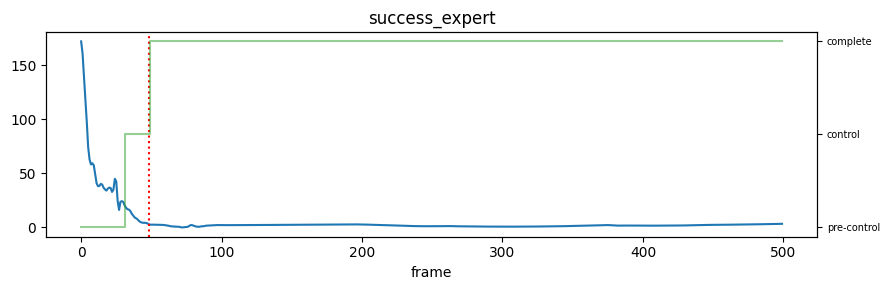

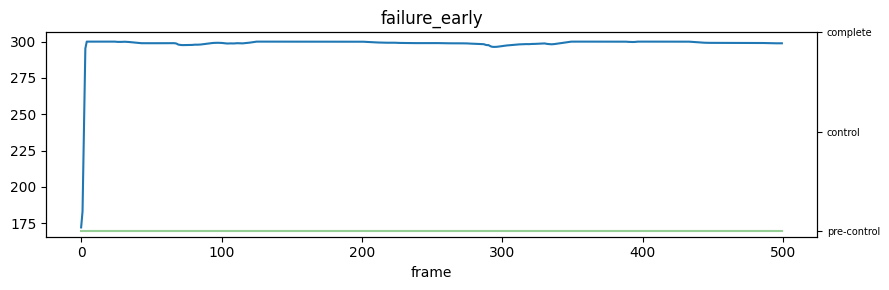

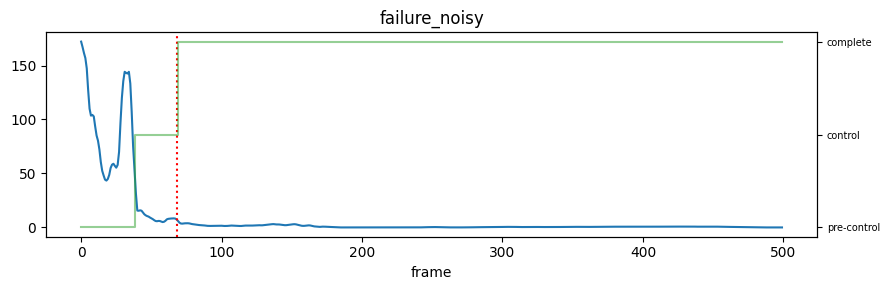

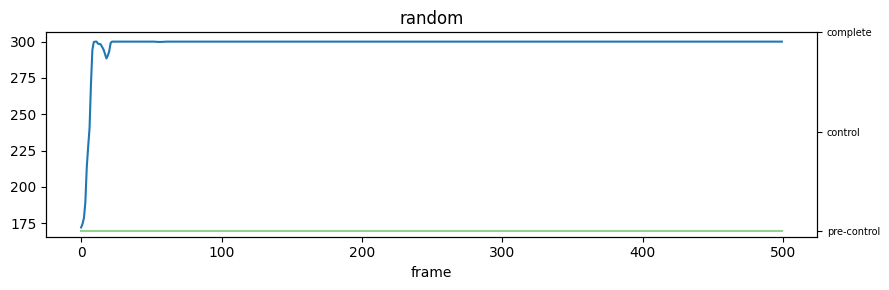

In [15]:
for name, r in results.items():
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(r["preds"], label="predicted steps")
    ax2 = ax.twinx()
    ax2.plot(r["stages"], color="tab:green", alpha=0.5, drawstyle="steps-post", label="stage")
    ax2.set_yticks([0, 1, 2]); ax2.set_yticklabels(STAGE_NAMES, fontsize=7)
    if r["success"] is not None:
        ax.axvline(r["success"], color="red", ls=":")
    ax.set_title(name); ax.set_xlabel("frame")
    plt.tight_layout(); plt.show()

In [ ]:
Video(results["success_expert"]["path"], embed=True)

In [ ]:
Video(results["failure_early"]["path"], embed=True)

In [ ]:
Video(results["failure_noisy"]["path"], embed=True)

In [ ]:
Video(results["random"]["path"], embed=True)

## 7. What to look for

Pause each video at a frame and compare against the plot above it:
- Does predicted-steps drop when the arm is visibly making progress (approaching,
  grasping, carrying toward the hole)?
- Does it stay flat or high while the arm is idle, flailing, or stuck?
- Does the stage line switch to "control" only once the peg visibly moves with
  the hand, not merely when the arm is nearby?

Disagreement between the curve and the video at a specific frame is worth
capturing as a still — that frame is a candidate for the stress-test set.

## 8. Held-but-not-inserted — forced miss

Lets the expert policy grasp and lift normally, then overrides the action to
steer sideways once holding is detected, so the peg is carried and held but
never brought to the hole. This is the specific case flagged as under-tested:
"holding the peg and failing to insert."

Compare its curve against `success_expert` and `failure_early` in Section 6 —
this is the case those two didn't cover.

In [16]:
def record_forced_miss(policy, out_path, scene_fn, max_steps=500, seed=0,
                        offset=np.array([0.15, 0.0, 0.0]),
                        peg_z_lifted=0.05, gripper_closed=0.6):
    """Runs normally until the peg is detected as lifted and held, then
    overrides the action to steer sideways — forcing a held-but-not-inserted
    outcome rather than hoping a policy naturally produces one."""
    env = scene_fn(render_mode="rgb_array", seed=seed)
    obs, _ = env.reset(seed=seed)
    frames, preds, stages = [], [], []
    success = None
    diverted = False
    divert_start = None
    direction = offset / np.linalg.norm(offset)

    for t in range(max_steps):
        frames.append(env.render())
        p, s = predict(obs)
        preds.append(p); stages.append(s)

        a, _ = policy.predict(obs, deterministic=True)

        peg_z = obs[PEG_POS_IDX][2]
        gripper = obs[3]
        if not diverted and peg_z > peg_z_lifted and gripper < gripper_closed:
            diverted = True
            divert_start = t
        if diverted:
            a = a.copy()
            a[:3] = direction    # overrides the policy's own direction — forced steer

        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
        if term or trunc:
            break
    env.close()
    imageio.mimsave(out_path, frames, fps=20)
    return dict(preds=np.array(preds), stages=np.array(stages),
                success=success, n=len(frames), path=out_path,
                diverted_at=divert_start)

held_miss = record_forced_miss(policies["expert_final"], "visual_check_held_miss.mp4",
                                make_fixed_scene_env, seed=0)
print(f"diverted at frame {held_miss['diverted_at']}, "
      f"success={held_miss['success']}, "
      f"pred at divert: {held_miss['preds'][held_miss['diverted_at']]:.1f}, "
      f"min pred after divert: {held_miss['preds'][held_miss['diverted_at']:].min():.1f}, "
      f"max pred after divert: {held_miss['preds'][held_miss['diverted_at']:].max():.1f}")
results["held_but_missed"] = held_miss

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


diverted at frame 33, success=None, pred at divert: 16.8, min pred after divert: 15.7, max pred after divert: 211.4


In [18]:
divert_idx = held_miss["diverted_at"]
post = held_miss["preds"][divert_idx:]
frames_since = np.arange(len(post))
print("correlation with frames-since-divert:", np.corrcoef(frames_since, post)[0,1])

correlation with frames-since-divert: 0.5308093212134858


### Compare against the other four, on shared axes

All five rollouts plotted together so the held-but-missed curve's behavior
after the divert point can be read directly against success and failure.

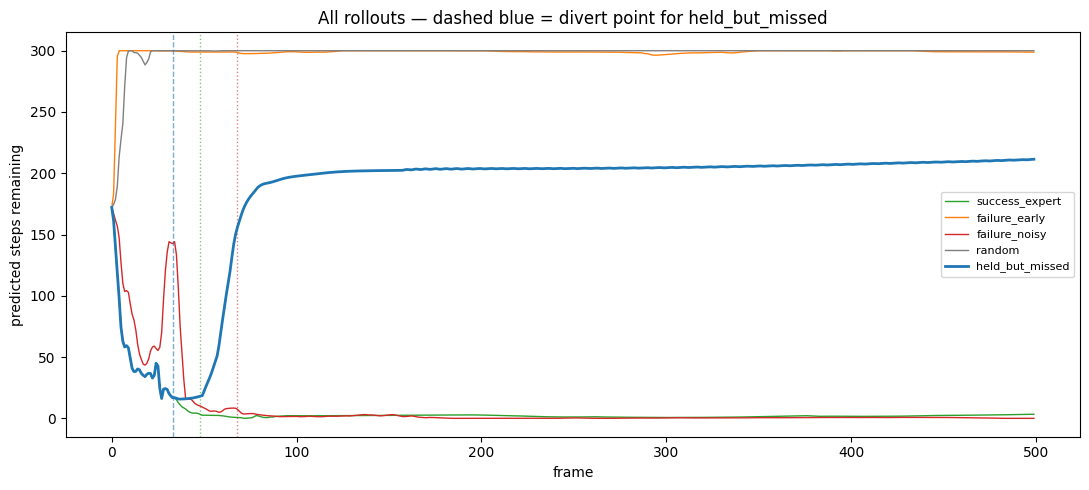

What this tests: does the prediction stay appropriately high/flat once
diverted (correct — held but not progressing toward insertion), or does
it collapse toward 0 the way it does for a real success (the exploit)?


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = {"success_expert": "tab:green", "failure_early": "tab:orange",
          "failure_noisy": "tab:red", "random": "tab:gray",
          "held_but_missed": "tab:blue"}
for name, r in results.items():
    ax.plot(r["preds"], label=name, color=colors.get(name), lw=2 if name == "held_but_missed" else 1)
    if r.get("diverted_at") is not None:
        ax.axvline(r["diverted_at"], color="tab:blue", ls="--", lw=1, alpha=0.6)
    if r["success"] is not None:
        ax.axvline(r["success"], color=colors.get(name), ls=":", lw=1, alpha=0.6)
ax.set_xlabel("frame"); ax.set_ylabel("predicted steps remaining")
ax.legend(fontsize=8)
ax.set_title("All rollouts — dashed blue = divert point for held_but_missed")
plt.tight_layout(); plt.show()

print("What this tests: does the prediction stay appropriately high/flat once")
print("diverted (correct — held but not progressing toward insertion), or does")
print("it collapse toward 0 the way it does for a real success (the exploit)?")

In [ ]:
Video(results["held_but_missed"]["path"], embed=True)

### Reading it

- **Prediction stays high/flat after the blue dashed line** — the model
  correctly distinguishes "holding, going nowhere" from "holding, about to
  succeed." Good result.
- **Prediction drops toward 0 despite the divert** — the model is keying on
  something correlated with holding (gripper state, height, general vicinity
  to the goal) rather than on the peg actually entering the hole. This would
  be the same overconfident-completion pattern found on the no-grasp exploit,
  now in the held-but-misaligned region.
- **Stage line** — check whether it snaps to "complete" after the divert.
  If it does without a real success flag, that is a labeling/detector
  question worth revisiting for this specific region.